In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
# load dataset
df = pd.read_csv("Social_Network_Ads.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Shape:", df.shape)

First 5 rows:
     User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Dataset Shape: (400, 5)


In [3]:
# remove unnecessary column
df = df.drop('User ID', axis=1)

In [4]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [5]:
# exact count of purchased product
print("\nPurchase count:\n", df['Purchased'].value_counts())


Purchase count:
 Purchased
0    257
1    143
Name: count, dtype: int64


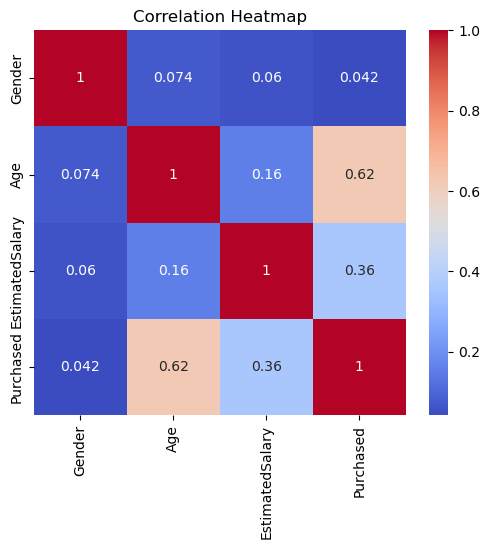

In [6]:
import seaborn as sns

# convert Gender to numeric
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# select numeric columns
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# correlation
corr = df_numeric.corr()

# plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [7]:
df.groupby('Purchased')[['Age', 'EstimatedSalary']].mean()

,Age,EstimatedSalary
Purchased,,
0,32.793774,60544.747082
1,46.391608,86272.727273


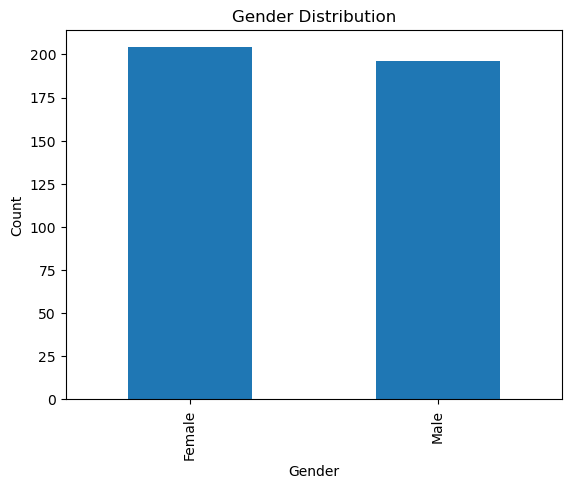

In [8]:
df['Gender_Label'] = df['Gender'].map({0: 'Male', 1: 'Female'})
df['Gender_Label'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [9]:
# select features & target
X = df[['Age', 'EstimatedSalary']]   # input
y = df['Purchased']                  # output

In [10]:
from sklearn.preprocessing import StandardScaler

# split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# then scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [12]:
# predictions
y_pred = model.predict(X_test)

# accuracy
print("\nTraining Accuracy: {:.2f}%".format(model.score(X_train, y_train)*100))
print("Testing Accuracy: {:.2f}%".format(model.score(X_test, y_test)*100))


Training Accuracy: 82.33%
Testing Accuracy: 89.00%


In [13]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[65  3]
 [ 8 24]]


In [14]:
# extract TP, TN, FP, FN
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("\nTP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)


TP: 24
TN: 65
FP: 3
FN: 8


In [17]:
# Evaluation metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.89
Error Rate: 0.10999999999999999
Precision: 0.8888888888888888
Recall: 0.75


In [16]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100

